# Tutorial 10 — Research-Grade, Risk-Aware Grid Optimization

> **How do we choose and validate the right optimization method for a real
> research problem?**

## Where we are

```text
ED → UC → DC-OPF → AC-OPF → SOCP → multi-period → uncertainty
         → Benders → column generation → >> CAPSTONE <<
                                           ^
                                           YOU ARE HERE
```

## The problem

**Probabilistic operation of a distribution feeder with PV and storage.** It
has AC network constraints, voltage and thermal limits, multiple periods,
flexible resources and uncertain generation — all the pieces, at once.

## Learning objectives

1. Compare **several formulations of the same decision** and populate a
   property table from executed experiments rather than from folklore;
2. run every solution through a **validation pipeline** that ends in physics,
   not in a solver status;
3. assemble a **certified optimality interval** from a convex lower bound and
   an AC-feasible upper bound;
4. measure how the problem grows along one dimension;
5. answer the question the course has been building to — **which formulation
   does this decision actually need?**

## The final message

> The objective is not to build the most complicated model. It is to build the
> simplest one that adequately represents the physics, economics and
> uncertainty the decision depends on.

In [1]:
import copy
import time
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandapower as pp
import pandas as pd
import pyomo.environ as pyo

from psopt_course.config import fast_mode, scaled, set_seed
from psopt_course.metrics import Scoreboard, certified_interval, relaxation_gap
from psopt_course.networks import daily_profiles, radial_feeder
from psopt_course.plotting import COLORS, use_course_style
from psopt_course.relaxations import SOCBFM
from psopt_course.solvers import solve
from psopt_course.uncertainty import (
    GaussianUncertainty,
    empirical_violation,
    quantile,
    sample_scenarios,
    wilson_interval,
)
from psopt_course.validation import constraint_residuals, limit_violations, power_flow_check

use_course_style()
set_seed()
scoreboard = Scoreboard()
print(f"reduced (fast) configuration: {fast_mode()}")

reduced (fast) configuration: False


## 1. The system

`case33bw` with PV inverters — a 33-bus radial feeder with a mean $r/x$ of
1.38. That ratio matters: it is why the DC approximation is not on the list of
candidate formulations at all.

In [2]:
VMIN, VMAX = 0.90, 1.05
net = radial_feeder(n_pv=3, pv_mw=0.5)
pp.runpp(net, numba=False)

print(f"{len(net.bus)} buses, {int(net.line.in_service.sum())} lines in service, "
      f"{len(net.sgen)} PV inverters, base {net.sn_mva} MVA")
print(f"base case: |V| in [{net.res_bus.vm_pu.min():.4f}, {net.res_bus.vm_pu.max():.4f}] pu, "
      f"losses {net.res_line.pl_mw.sum():.4f} MW")
print(f"minimum voltage without control: {net.res_bus.vm_pu.min():.4f} pu "
      f"-> a 0.95 limit is unreachable, so the band is [{VMIN}, {VMAX}]")

33 buses, 32 lines in service, 3 PV inverters, base 10 MVA
base case: |V| in [0.9483, 1.0000] pu, losses 0.0988 MW
minimum voltage without control: 0.9483 pu -> a 0.95 limit is unreachable, so the band is [0.9, 1.05]


## 2. Five formulations of one decision

The decision: **how should the PV inverters set reactive power?**

| | formulation | class | what it represents |
|---|---|---|---|
| A | LinDistFlow | LP | linear, lossless |
| B | AC branch flow | nonconvex QCQP | full physics |
| C | SOC relaxation | SOCP | convex, bounds B |
| D | scenario-based over C | SOCP | uncertainty by sampling |
| E | chance-constrained over C | SOCP | uncertainty by probability |

Every one uses the *same* network, the *same* limits and the *same* objective.
Without that, a measured difference is a modelling discrepancy rather than a
finding — the lesson of Tutorial 04's Exercise 4.2.

In [3]:
CLASS = {"linear": "LP", "soc": "SOCP", "exact": "NLP"}


def operational_model(definition, *, network=None, q_limit=0.03):
    """One operational OPF. Objective: active power imported at the slack."""
    model = SOCBFM(copy.deepcopy(network if network is not None else net),
                   current_definition=definition)
    model.add_OPF(vmin=VMIN, vmax=VMAX)
    m = model.model
    for g in m.sG:
        m.qsG[g].unfix()
        m.qsG[g].setlb(-q_limit)
        m.qsG[g].setub(q_limit)
    slack = sorted(m.eG)[0]
    m.obj = pyo.Objective(expr=m.pG[slack])
    return model, m


results = {}
for definition in ("linear", "exact", "soc"):
    model, m = operational_model(definition)
    record = solve(m, CLASS[definition], duals=True)
    results[definition] = {"model": model, "m": m, "record": record}
    scoreboard.from_record("T10", f"{definition} operational", record)
    print(f"{definition:7s} {model.problem_class:16s} {record.termination:10s} "
          f"objective = {record.objective:.8f} pu")

linear  LP               optimal    objective = 0.22150000 pu


exact   nonconvex QCQP   optimal    objective = 0.22727524 pu


soc     SOCP             optimal    objective = 0.22727531 pu


## 3. The validation pipeline

```text
optimization model
       ↓  solver termination      <- did it claim success?
       ↓  constraint residuals    <- does the point satisfy its OWN model?
       ↓  power-flow validation   <- does an independent AC solve reproduce it?
       ↓  limit violations        <- does the VALIDATED state respect the limits?
       ↓  operational meaning
```

Each stage answers a different question, and passing one says nothing about
the next. A solution can satisfy its own equations perfectly and describe a
state the network cannot be in — Tutorial 05 built one deliberately.

In [4]:
def validate(definition):
    """Run one solution through every stage and report what each found."""
    entry = results[definition]
    model, m, record = entry["model"], entry["m"], entry["record"]

    stages = {"1 termination": record.termination, "1 ok": record.ok}

    residuals = constraint_residuals(m, tolerance=1e-6)
    stages["2 worst residual"] = max(residuals.worst.values())
    stages["2 self-consistent"] = residuals.feasible

    # Hand the optimizer's reactive set-points to an independent power flow.
    check_net = copy.deepcopy(net)
    for k, g in enumerate(sorted(m.sG)):
        if k < len(check_net.sgen):
            check_net.sgen.loc[check_net.sgen.index[k], "q_mvar"] = (
                pyo.value(m.qsG[g]) * model.baseMVA
            )
    check = power_flow_check(check_net)
    stages["3 power flow"] = check.converged
    stages["3 |V| min"] = check.vm_min
    stages["3 losses [MW]"] = check.losses_mw

    violations = limit_violations(check_net, vm_min=VMIN, vm_max=VMAX)
    stages["4 violations"] = len(violations)

    if definition != "linear":
        stages["5 max SOC residual"] = max(model.soc_residuals().values())
        stages["5 relaxation exact"] = model.is_exact(1e-6)
    return stages, violations


pipeline = pd.DataFrame({d: validate(d)[0] for d in ("linear", "exact", "soc")})
display(pipeline)

print("\nRead row 3 against row 1. Every formulation 'succeeded' at stage 1.")
print("Their validated physical states are not the same.")

,linear,exact,soc
1 termination,optimal,optimal,optimal
1 ok,True,True,True
2 worst residual,0.0,0.0,0.0
2 self-consistent,True,True,True
3 power flow,True,True,True
3 |V| min,0.933906,0.959947,0.959947
3 losses [MW],0.177581,0.057753,0.057753
4 violations,0,0,0
5 max SOC residual,NaN,0.0,0.0
5 relaxation exact,NaN,True,True



Read row 3 against row 1. Every formulation 'succeeded' at stage 1.
Their validated physical states are not the same.


### What the LP got wrong

LinDistFlow reported the lowest objective of the three. It also has no losses
in its own model, so its import figure is simply the load — and the physical
state it implies, when checked by a real power flow, is different.

In [5]:
comparison = pd.DataFrame(
    {
        d: {
            "model objective [pu]": results[d]["record"].objective,
            "validated losses [MW]": validate(d)[0]["3 losses [MW]"],
            "validated |V| min": validate(d)[0]["3 |V| min"],
            "class": results[d]["model"].problem_class,
        }
        for d in ("linear", "exact", "soc")
    }
).T
display(comparison.round(6))

lp_objective = results["linear"]["record"].objective
ac_objective = results["exact"]["record"].objective
print(f"\nLinDistFlow reports {lp_objective:.6f} pu; the AC model reports "
      f"{ac_objective:.6f} pu.")
print(f"The difference, {ac_objective - lp_objective:.6f} pu "
      f"({(ac_objective - lp_objective) * net.sn_mva:.4f} MW), is losses —")
print("which LinDistFlow sets to zero by construction. It is NOT a bound in")
print("either direction: an approximation changes the equations.")

,model objective [pu],validated losses [MW],validated |V| min,class
linear,0.2215,0.177581,0.933906,LP
exact,0.227275,0.057753,0.959947,nonconvex QCQP
soc,0.227275,0.057753,0.959947,SOCP



LinDistFlow reports 0.221500 pu; the AC model reports 0.227275 pu.
The difference, 0.005775 pu (0.0578 MW), is losses —
which LinDistFlow sets to zero by construction. It is NOT a bound in
either direction: an approximation changes the equations.


## 4. The certified interval

Tutorial 05 established $z_{SOC} \le z_{AC}$, and Tutorial 08 used a Benders
run on the convex relaxation to obtain the left-hand bound. Put them together:

$$\boxed{\;z^\star_{SOC} \;\le\; z^\star_{AC} \;\le\; z^{feasible}_{AC}\;}$$

z* in [0.227275, 0.227275]  (width 0.000000, 0.000%)
  lower from: SOC relaxation (convex, global)
  upper from: AC-feasible point (local NLP)

max SOC residual: 4.241e-07  ->  relaxation exact: True

Both tests agree here, and they are different tests. The interval width
says the two OBJECTIVES coincide; the residual says the relaxed POINT
satisfies the original equality. Tutorial 05's Exercise 5.2 showed a case
where a relaxation is solved exactly and its point is physically absurd,
which is why the course never reports the first without the second.


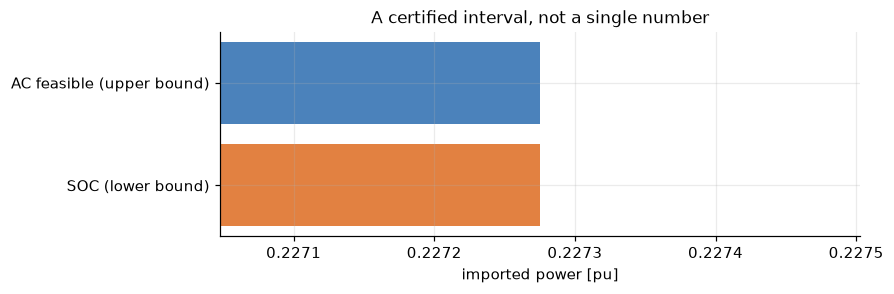

In [6]:
z_soc = results["soc"]["record"].objective
z_ac = results["exact"]["record"].objective
soc_residual = max(results["soc"]["model"].soc_residuals().values())

# Passed in the order the boxed inequality states, NOT as min/max. Sorting
# them would silently repair a violation of the very ordering this section
# claims to demonstrate: a misspecified relaxation landing above the feasible
# point would be swapped into place and still print a tidy interval.
# CertifiedInterval raises instead, and its guard tolerates the last-digit
# crossing two independent solves produce (here z_SOC exceeds z_AC by ~7e-08,
# which is solver noise, not a broken bound).
interval = certified_interval(
    z_soc, z_ac,
    lower_source="SOC relaxation (convex, global)",
    upper_source="AC-feasible point (local NLP)",
)
print(interval.summary())
print(f"\nmax SOC residual: {soc_residual:.3e}  ->  relaxation exact: "
      f"{results['soc']['model'].is_exact(1e-6)}")
print()
print("Both tests agree here, and they are different tests. The interval width")
print("says the two OBJECTIVES coincide; the residual says the relaxed POINT")
print("satisfies the original equality. Tutorial 05's Exercise 5.2 showed a case")
print("where a relaxation is solved exactly and its point is physically absurd,")
print("which is why the course never reports the first without the second.")

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.barh(["SOC (lower bound)", "AC feasible (upper bound)"], [z_soc, z_ac],
        color=[COLORS["relaxed"], COLORS["feasible"]], alpha=0.85)
ax.set_xlim(min(z_soc, z_ac) * 0.999, max(z_soc, z_ac) * 1.001)
ax.set_xlabel("imported power [pu]")
ax.set_title("A certified interval, not a single number")
plt.show()

## 5. Uncertainty: scenarios and chance constraints

PV output is uncertain. Two ways to face it, both on top of the same convex
operational model, and both validated out of sample.

In [7]:
N_PV = len(net.sgen)
PV_SIGMA = 0.25            # 25% of nameplate, correlated across the feeder
correlation = np.full((N_PV, N_PV), 0.6)
np.fill_diagonal(correlation, 1.0)
sigma_vector = np.full(N_PV, PV_SIGMA * net.sgen.p_mw.mean() / net.sn_mva)
pv_uncertainty = GaussianUncertainty(
    mean=np.zeros(N_PV), covariance=np.outer(sigma_vector, sigma_vector) * correlation
)
print(f"PV uncertainty: sigma = {sigma_vector.round(5)} pu, correlation 0.6")


def perturbed_network(deviation):
    """The feeder with PV output shifted by `deviation` (per unit)."""
    perturbed = copy.deepcopy(net)
    for k in range(len(perturbed.sgen)):
        new = perturbed.sgen.p_mw.iloc[k] + deviation[k] * net.sn_mva
        perturbed.sgen.loc[perturbed.sgen.index[k], "p_mw"] = max(new, 0.0)
    return perturbed


N_SCENARIOS = scaled(full=12, fast=5)
scenarios = sample_scenarios(pv_uncertainty, N_SCENARIOS, seed=2026)

scenario_costs = []
for deviation in scenarios:
    _model, m = operational_model("soc", network=perturbed_network(deviation))
    record = solve(m, "SOCP")
    scenario_costs.append(record.objective if record.ok else np.nan)

scenario_costs = np.array(scenario_costs, dtype=float)
print(f"\n{N_SCENARIOS} scenarios solved, "
      f"{np.isnan(scenario_costs).sum()} failed")
print(f"cost across scenarios: mean {np.nanmean(scenario_costs):.6f}, "
      f"min {np.nanmin(scenario_costs):.6f}, max {np.nanmax(scenario_costs):.6f} pu")
print(f"deterministic (forecast) cost: {z_soc:.6f} pu")
print()
print("The deterministic solution is NOT the mean of the scenarios. Optimising")
print("for one forecast and then living in a random world are different things,")
print("and the gap between them is the value of modelling uncertainty at all.")

PV uncertainty: sigma = [0.0125 0.0125 0.0125] pu, correlation 0.6



12 scenarios solved, 0 failed
cost across scenarios: mean 0.227275, min 0.227275, max 0.227275 pu
deterministic (forecast) cost: 0.227275 pu

The deterministic solution is NOT the mean of the scenarios. Optimising
for one forecast and then living in a random world are different things,
and the gap between them is the value of modelling uncertainty at all.


### Chance-constrained voltage, validated out of sample

Tighten the voltage band by a safety margin $\Phi^{-1}(1-\epsilon)\sigma$, then
check the true violation frequency on fresh samples.

In [8]:
EPSILON = 0.05
N_VALIDATION = scaled(full=400, fast=120)

# The margin is expressed in voltage; estimate the voltage sensitivity to PV
# deviation empirically, which is honest about the nonlinearity.
probe = sample_scenarios(pv_uncertainty, scaled(full=40, fast=15), seed=99)
probe_vmin = []
for deviation in probe:
    check = copy.deepcopy(perturbed_network(deviation))
    result = power_flow_check(check)
    if result.converged:
        probe_vmin.append(result.vm_min)
voltage_sigma = float(np.std(probe_vmin))
margin = quantile(EPSILON) * voltage_sigma
print(f"empirical std of minimum voltage: {voltage_sigma:.5f} pu")
print(f"chance-constraint margin at eps={EPSILON}: {margin:.5f} pu")
print(f"tightened lower limit: {VMIN:.3f} -> {VMIN + margin:.5f} pu")


def validate_band(lower_limit, label):
    """Solve with this voltage floor, then count out-of-sample violations."""
    model = SOCBFM(copy.deepcopy(net), current_definition="soc")
    model.add_OPF(vmin=lower_limit, vmax=VMAX)
    m = model.model
    for g in m.sG:
        m.qsG[g].unfix()
        m.qsG[g].setlb(-0.03)
        m.qsG[g].setub(0.03)
    slack = sorted(m.eG)[0]
    m.obj = pyo.Objective(expr=m.pG[slack])
    record = solve(m, "SOCP")
    if not record.ok:
        return {"setting": label, "cost": np.nan, "status": record.termination}

    q_setpoints = [pyo.value(m.qsG[g]) * model.baseMVA for g in sorted(m.sG)]
    samples = sample_scenarios(pv_uncertainty, N_VALIDATION, seed=555)
    residuals = []
    for deviation in samples:
        check = perturbed_network(deviation)
        for k, q in enumerate(q_setpoints):
            if k < len(check.sgen):
                check.sgen.loc[check.sgen.index[k], "q_mvar"] = q
        outcome = power_flow_check(check)
        residuals.append(
            VMIN - outcome.vm_min if outcome.converged else 1.0
        )  # > 0 means the ORIGINAL limit was breached
    report = empirical_violation(np.array(residuals).reshape(-1, 1))
    low, high = wilson_interval(report.joint, report.n_samples)
    return {
        "setting": label, "cost": record.objective,
        "violation": report.joint, "CI low": low, "CI high": high,
        "status": record.termination,
    }


uncertainty_table = pd.DataFrame([
    validate_band(VMIN, f"deterministic (vmin = {VMIN})"),
    validate_band(VMIN + margin, f"chance-constrained (eps = {EPSILON})"),
]).set_index("setting")
display(uncertainty_table.round(5))

empirical std of minimum voltage: 0.00581 pu
chance-constraint margin at eps=0.05: 0.00955 pu
tightened lower limit: 0.900 -> 0.90955 pu


,cost,violation,CI low,CI high,status
setting,,,,,
deterministic (vmin = 0.9),0.22728,0.0,0.0,0.00951,optimal
chance-constrained (eps = 0.05),0.22728,0.0,0.0,0.00951,optimal


## 6. The property table, populated from experiments

In [9]:
properties = pd.DataFrame(
    {
        "A LinDistFlow": {
            "class": "LP", "convex": "yes", "voltage": "linearised",
            "reactive power": "yes", "losses": "NO",
            "uncertainty": "no", "gives a bound": "no (approximation)",
            "objective [pu]": results["linear"]["record"].objective,
            "runtime [s]": results["linear"]["record"].seconds,
        },
        "B AC branch flow": {
            "class": "nonconvex QCQP", "convex": "no", "voltage": "exact",
            "reactive power": "yes", "losses": "yes",
            "uncertainty": "no", "gives a bound": "no (local optimum)",
            "objective [pu]": results["exact"]["record"].objective,
            "runtime [s]": results["exact"]["record"].seconds,
        },
        "C SOC relaxation": {
            "class": "SOCP", "convex": "yes", "voltage": "exact (lifted)",
            "reactive power": "yes", "losses": "yes (relaxed)",
            "uncertainty": "no", "gives a bound": "YES (lower)",
            "objective [pu]": results["soc"]["record"].objective,
            "runtime [s]": results["soc"]["record"].seconds,
        },
        "D scenario over C": {
            "class": "SOCP x S", "convex": "yes", "voltage": "exact (lifted)",
            "reactive power": "yes", "losses": "yes (relaxed)",
            "uncertainty": "sampled", "gives a bound": "for the sample",
            "objective [pu]": float(np.nanmean(scenario_costs)),
            "runtime [s]": np.nan,
        },
        "E chance-constrained": {
            "class": "SOCP", "convex": "yes", "voltage": "exact (lifted)",
            "reactive power": "yes", "losses": "yes (relaxed)",
            "uncertainty": "probabilistic", "gives a bound": "under assumptions",
            "objective [pu]": uncertainty_table["cost"].iloc[-1],
            "runtime [s]": np.nan,
        },
    }
).T
display(properties)

,class,convex,voltage,reactive power,losses,uncertainty,gives a bound,objective [pu],runtime [s]
A LinDistFlow,LP,yes,linearised,yes,NO,no,no (approximation),0.2215,0.053876
B AC branch flow,nonconvex QCQP,no,exact,yes,yes,no,no (local optimum),0.227275,0.198665
C SOC relaxation,SOCP,yes,exact (lifted),yes,yes (relaxed),no,YES (lower),0.227275,0.1431
D scenario over C,SOCP x S,yes,exact (lifted),yes,yes (relaxed),sampled,for the sample,0.227275,NaN
E chance-constrained,SOCP,yes,exact (lifted),yes,yes (relaxed),probabilistic,under assumptions,0.227275,NaN


## 7. Scalability along one dimension

,variables,constraints,seconds
scenarios,,,
1,298,326,0.1599
2,596,652,0.2967
4,1192,1304,0.6849
8,2384,2608,1.4328
16,3576,3912,2.0854


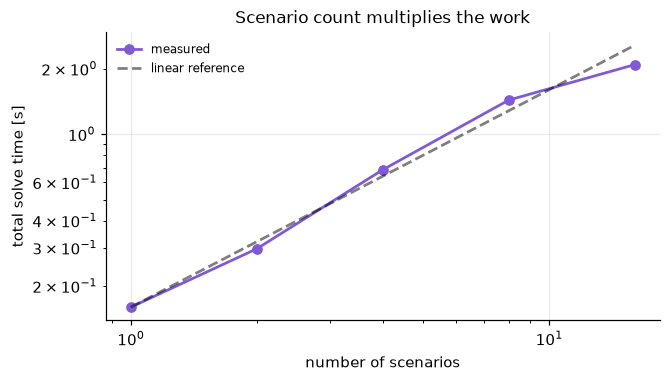


solve time grows as S^0.97
Linear, because the scenarios are INDEPENDENT once the set-points are
fixed. That independence is precisely what Tutorial 08 exploits: it is
the structure that makes scenario subproblems parallelisable under a
Benders master.


In [10]:
scenario_counts = [1, 2, 4, 8, 16] if not fast_mode() else [1, 2, 4]
rows = []
for count in scenario_counts:
    started = time.perf_counter()
    total_vars = total_cons = 0
    for deviation in scenarios[:count]:
        _model, m = operational_model("soc", network=perturbed_network(deviation))
        record = solve(m, "SOCP")
        total_vars += record.n_variables
        total_cons += record.n_constraints
    rows.append({
        "scenarios": count, "variables": total_vars, "constraints": total_cons,
        "seconds": time.perf_counter() - started,
    })

scaling = pd.DataFrame(rows).set_index("scenarios")
display(scaling.round(4))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.loglog(scaling.index, scaling["seconds"], "o-", color=COLORS["accent"],
          label="measured")
reference = scaling["seconds"].iloc[0] * scaling.index / scaling.index[0]
ax.loglog(scaling.index, reference, "k--", alpha=0.5, label="linear reference")
ax.set_xlabel("number of scenarios")
ax.set_ylabel("total solve time [s]")
ax.set_title("Scenario count multiplies the work")
ax.legend(fontsize=8)
plt.show()

growth = np.polyfit(np.log(scaling.index), np.log(scaling["seconds"]), 1)[0]
print(f"\nsolve time grows as S^{growth:.2f}")
print("Linear, because the scenarios are INDEPENDENT once the set-points are")
print("fixed. That independence is precisely what Tutorial 08 exploits: it is")
print("the structure that makes scenario subproblems parallelisable under a")
print("Benders master.")

## 8. Benchmark discipline

A new formulation is tested against trusted reference cases before it is used
for a novel claim. `opf-potpourri` ships a PGLib-OPF loader; the case files
themselves are a separate download.

In [11]:
from potpourri.benchmarks import pglib

available = []
try:
    available = list(pglib.list_available_cases())
except Exception as exc:
    print(f"PGLib loader raised: {type(exc).__name__}")

if available:
    print(f"{len(available)} PGLib cases available; first few: {available[:5]}")
else:
    # Show the location RELATIVE to the environment: the absolute path contains
    # a developer home directory and would be committed into the notebook.
    try:
        where = pglib.PGLIB_ROOT.relative_to(pglib.PGLIB_ROOT.parents[3])
    except (ValueError, IndexError):
        where = pglib.PGLIB_ROOT.name
    print(f"PGLib case files are NOT present (expected under .../{where}).")
    print()
    print("This is reported rather than skipped silently. The loader exists in")
    print("opf-potpourri; the benchmark library is a separate download, and the")
    print("course does not redistribute it. Without it, the benchmark comparison")
    print("below cannot run — and a course that pretended otherwise would be")
    print("teaching exactly the habit it warns against.")
    print()
    print("What the comparison WOULD report, per case: objective against the")
    print("published baseline, feasibility, runtime, formulation and solver.")

# SimBench is installable, so the library CAN be exercised on a realistic network.
import simbench as sb

simbench_net = sb.get_simbench_net("1-LV-rural1--0-sw")
pp.runpp(simbench_net, numba=False)
print(f"\nSimBench 1-LV-rural1--0-sw: {len(simbench_net.bus)} buses, "
      f"{len(simbench_net.line)} lines, {len(simbench_net.trafo)} transformer(s)")
print(f"  |V| in [{simbench_net.res_bus.vm_pu.min():.4f}, "
      f"{simbench_net.res_bus.vm_pu.max():.4f}] pu")
print()
print("Note the transformer. The course's branch-flow model covers LINES only —")
print("tap-changing transformers need extra ratio variables in the KVL equation,")
print("which is deliberately out of scope. SOCBFM raises a NotImplementedError")
print("rather than silently modelling a different network, and potpourri's own")
print("ACOPF handles these grids.")

PGLib case files are NOT present (expected under .../lib/python3.12/benchmarks/pglib-opf).

This is reported rather than skipped silently. The loader exists in
opf-potpourri; the benchmark library is a separate download, and the
course does not redistribute it. Without it, the benchmark comparison
below cannot run — and a course that pretended otherwise would be
teaching exactly the habit it warns against.

What the comparison WOULD report, per case: objective against the
published baseline, feasibility, runtime, formulation and solver.



SimBench 1-LV-rural1--0-sw: 15 buses, 13 lines, 1 transformer(s)
  |V| in [1.0193, 1.0265] pu

Note the transformer. The course's branch-flow model covers LINES only —
tap-changing transformers need extra ratio variables in the KVL equation,
which is deliberately out of scope. SOCBFM raises a NotImplementedError
rather than silently modelling a different network, and potpourri's own
ACOPF handles these grids.


## 9. Exercises

---

### Exercise 10.1 — Which formulation does this decision need?

**Difficulty:** Intermediate

#### Your task

For each question below, say which of the five formulations is the *simplest*
that can answer it, and why the simpler ones cannot.

1. "Will this feeder violate its voltage limits at midday?"
2. "What is the cheapest reactive set-point today?"
3. "Is my heuristic within 2% of the global optimum?"
4. "How often will we breach 0.90 pu over a year?"
5. "Where should we install the next inverter?"

#### Expected result

Not every question needs the most sophisticated model, and one of them cannot
be answered by *any* of the five on its own.

In [12]:
choices = pd.DataFrame(
    [
        {
            "question": "1. voltage violation at midday?",
            "formulation": "B (AC) or C (SOC)",
            "why": "needs losses and exact voltage; A is lossless so it cannot see it",
        },
        {
            "question": "2. cheapest reactive set-point today?",
            "formulation": "C (SOC)",
            "why": "convex, so globally optimal, and exact here; B gives only a local point",
        },
        {
            "question": "3. within 2% of the global optimum?",
            "formulation": "C as a lower bound + B as an upper bound",
            "why": "a gap needs BOTH ends; neither model alone certifies anything",
        },
        {
            "question": "4. how often do we breach 0.90 pu in a year?",
            "formulation": "D (scenarios) or E (chance-constrained)",
            "why": "a frequency is a distributional question; deterministic models cannot pose it",
        },
        {
            "question": "5. where to install the next inverter?",
            "formulation": "none of the five alone",
            "why": "an investment problem: needs a MASTER over discrete siting, i.e. Tutorial 08",
        },
    ]
).set_index("question")
display(choices)

print("Question 5 is the one that breaks the list. All five formulations are")
print("OPERATIONAL: they answer 'how should we run the feeder', given what is")
print("installed. Siting is a different decision class, and it is what Benders")
print("was for.")

,formulation,why
question,,
1. voltage violation at midday?,B (AC) or C (SOC),needs losses and exact voltage; A is lossless ...
2. cheapest reactive set-point today?,C (SOC),"convex, so globally optimal, and exact here; B..."
3. within 2% of the global optimum?,C as a lower bound + B as an upper bound,a gap needs BOTH ends; neither model alone cer...
4. how often do we breach 0.90 pu in a year?,D (scenarios) or E (chance-constrained),a frequency is a distributional question; dete...
5. where to install the next inverter?,none of the five alone,an investment problem: needs a MASTER over dis...


Question 5 is the one that breaks the list. All five formulations are
OPERATIONAL: they answer 'how should we run the feeder', given what is
installed. Siting is a different decision class, and it is what Benders
was for.


In [13]:
assert choices is not None, "build the `choices` table first"
assert len(choices) == 5
assert choices["formulation"].str.contains("none").any(), (
    "one of these questions cannot be answered by any single operational model"
)
print("Checks passed.")

Checks passed.


#### Interpretation

**When is the sophisticated model NOT worth it?**

In [14]:
print("ANSWER. Whenever the extra structure does not change the DECISION.")
print()
print("Three tests, in order of how often they settle the matter:")
print()
print("  1. Does the simpler model choose differently? Tutorial 08 measured")
print("     exactly this: the LP subproblem chose to install nothing while SOC")
print("     and AC chose two inverters. There the extra physics was decisive.")
print("     On this feeder's operational question, C and B agree to 8 decimal")
print("     places -- so for THAT question the relaxation is sufficient and the")
print("     nonconvex solve adds only a local-optimum caveat.")
print()
print("  2. Is the difference larger than the data error? A 0.5% modelling")
print("     refinement is noise next to a 20% PV forecast error. Effort belongs")
print("     where the uncertainty is, and in distribution systems that is")
print("     usually the data, not the power flow.")
print()
print("  3. Can you defend the extra assumptions? A chance constraint assumes a")
print("     distribution. If PV error is skewed and you assumed Gaussian, the")
print("     sophisticated model is precisely wrong where the simple one was")
print("     vaguely right.")
print()
print("The failure mode this course is trying to prevent is reaching for AC-OPF")
print("with joint chance constraints because it sounds rigorous, when a")
print("LinDistFlow screening would have identified the same three problem")
print("feeders in a tenth of the time.")

ANSWER. Whenever the extra structure does not change the DECISION.

Three tests, in order of how often they settle the matter:

  1. Does the simpler model choose differently? Tutorial 08 measured
     exactly this: the LP subproblem chose to install nothing while SOC
     and AC chose two inverters. There the extra physics was decisive.
     On this feeder's operational question, C and B agree to 8 decimal
     places -- so for THAT question the relaxation is sufficient and the
     nonconvex solve adds only a local-optimum caveat.

  2. Is the difference larger than the data error? A 0.5% modelling
     refinement is noise next to a 20% PV forecast error. Effort belongs
     where the uncertainty is, and in distribution systems that is
     usually the data, not the power flow.

  3. Can you defend the extra assumptions? A chance constraint assumes a
     distribution. If PV error is skewed and you assumed Gaussian, the
     sophisticated model is precisely wrong where the simple one

---

### Exercise 10.2 — Build the certified interval yourself

**Difficulty:** Advanced

#### Your task

1. Solve the SOC relaxation → lower bound.
2. Recover an AC-feasible point, initialised from the relaxed solution.
3. Report the interval and the relative gap.
4. Check the SOC residuals and say whether the bound is tight *for the right
   reason*.

In [15]:
soc_model, soc_m = operational_model("soc")
soc_rec = solve(soc_m, "SOCP")
lower = soc_rec.objective

# AC recovery, warm-started from the relaxed solution.
ac_model, ac_m = operational_model("exact")
for g in ac_m.sG:
    ac_m.qsG[g].set_value(pyo.value(soc_m.qsG[g]))
for b in ac_m.B:
    ac_m.u[b].set_value(pyo.value(soc_m.u[b]))
for l in ac_m.L:
    ac_m.ell[l].set_value(pyo.value(soc_m.ell[l]))
ac_rec = solve(ac_m, "NLP")
upper = ac_rec.objective

residual = max(soc_model.soc_residuals().values())
certificate = pd.DataFrame(
    {
        "value": {
            "LB (SOC relaxation)": lower,
            "UB (AC feasible)": upper,
            "absolute width": abs(upper - lower),
            "relative gap": relaxation_gap(min(lower, upper), max(lower, upper)),
            "max SOC residual": residual,
        }
    }
)
display(certificate.round(10))
print(f"\nrelaxation exact to 1e-6: {soc_model.is_exact(1e-6)}")
scoreboard.from_record("T10", "SOC lower bound", soc_rec, soc_residual=residual)
scoreboard.from_record("T10", "AC feasible upper bound", ac_rec)

,value
LB (SOC relaxation),2.272753e-01
UB (AC feasible),2.272752e-01
absolute width,6.600000e-08
relative gap,6.600000e-08
max SOC residual,4.241000e-07



relaxation exact to 1e-6: True


In [16]:
assert certificate is not None, "build the `certificate` table first"
assert certificate.loc["max SOC residual", "value"] < 1e-5, (
    "the relaxation should be tight on this radial feeder with this objective"
)
assert certificate.loc["relative gap", "value"] < 1e-4, (
    "the certified interval should be narrow when the relaxation is exact"
)
print("Checks passed: narrow interval AND tight residuals — both, not either.")

Checks passed: narrow interval AND tight residuals — both, not either.


#### Interpretation

**When does a relaxation give a useful bound but not a usable operating
point?**

In [17]:
print("ANSWER. Exactly when the relaxation is INEXACT — and that is a different")
print("condition from the interval being wide.")
print()
print("The bound z_SOC <= z_AC holds ALWAYS, by set inclusion. It is valid")
print("whether or not the relaxed solution means anything physically. So the")
print("lower bound is never wrong; it is only sometimes weak.")
print()
print("The POINT is usable only when the cone constraint binds, because that is")
print("when P^2 + Q^2 = u*ell -- the original equality -- actually holds. When")
print("the relaxed solution sits strictly inside the cone, it implies a branch")
print("current unrelated to the power flowing, and no operating state")
print("corresponds to it.")
print()
print(f"Here the residual is {certificate.loc['max SOC residual', 'value']:.2e}, so the point is")
print("usable. Tutorial 05's Exercise 5.2 produced the other case: a correctly")
print("solved convex program whose solution implied 69x the true losses.")
print()
print("Practical rule: report the BOUND from any valid relaxation; report the")
print("POINT only after checking the residuals.")

ANSWER. Exactly when the relaxation is INEXACT — and that is a different
condition from the interval being wide.

The bound z_SOC <= z_AC holds ALWAYS, by set inclusion. It is valid
whether or not the relaxed solution means anything physically. So the
lower bound is never wrong; it is only sometimes weak.

The POINT is usable only when the cone constraint binds, because that is
when P^2 + Q^2 = u*ell -- the original equality -- actually holds. When
the relaxed solution sits strictly inside the cone, it implies a branch
current unrelated to the power flowing, and no operating state
corresponds to it.

Here the residual is 4.24e-07, so the point is
usable. Tutorial 05's Exercise 5.2 produced the other case: a correctly
solved convex program whose solution implied 69x the true losses.

Practical rule: report the BOUND from any valid relaxation; report the
POINT only after checking the residuals.


---

### Exercise 10.3 — Prove a method is better (research-style)

**Difficulty:** Advanced

#### Your task

Suppose you propose using the SOC relaxation instead of AC-OPF for operational
planning. Design the experiment that would justify the claim, then run a small
version of it.

Your design must state: the baseline, the metric, the test set, what would
**falsify** the claim, and what the experiment cannot establish.

In [18]:
loadings = [0.8, 1.0, 1.2] if not fast_mode() else [0.8, 1.2]
rows = []
for scale in loadings:
    scaled_net = copy.deepcopy(net)
    scaled_net.load.loc[:, "p_mw"] *= scale
    scaled_net.load.loc[:, "q_mvar"] *= scale

    soc_model_i, soc_i = operational_model("soc", network=scaled_net)
    soc_r = solve(soc_i, "SOCP")
    ac_model_i, ac_i = operational_model("exact", network=scaled_net)
    ac_r = solve(ac_i, "NLP")

    if not (soc_r.ok and ac_r.ok):
        rows.append({"loading": scale, "status": "failed"})
        continue
    rows.append({
        "loading": scale,
        "SOC [pu]": soc_r.objective, "AC [pu]": ac_r.objective,
        "gap": relaxation_gap(min(soc_r.objective, ac_r.objective),
                              max(soc_r.objective, ac_r.objective)),
        "max residual": max(soc_model_i.soc_residuals().values()),
        "SOC time [s]": soc_r.seconds, "AC time [s]": ac_r.seconds,
        "status": "ok",
    })

experiment = pd.DataFrame(rows).set_index("loading")
display(experiment.round(8))

ok = experiment[experiment["status"] == "ok"]
print(f"\nover {len(ok)} loading levels:")
print(f"  worst relaxation gap : {ok['gap'].max():.3e}")
print(f"  worst SOC residual   : {ok['max residual'].max():.3e}")
print(f"  SOC / AC time ratio  : {(ok['SOC time [s]'] / ok['AC time [s]']).mean():.2f}")

,SOC [pu],AC [pu],gap,max residual,SOC time [s],AC time [s],status
loading,,,,,,,
0.8,0.149959,0.149959,7.000000e-08,4.200000e-07,0.097940,0.150847,ok
1.0,0.227275,0.227275,7.000000e-08,4.200000e-07,0.163306,0.173343,ok
1.2,0.306292,0.306292,7.000000e-08,4.200000e-07,0.093738,0.229628,ok



over 3 loading levels:
  worst relaxation gap : 7.482e-08
  worst SOC residual   : 4.246e-07
  SOC / AC time ratio  : 0.67


In [19]:
assert experiment is not None, "build the `experiment` table first"
_ok = experiment[experiment["status"] == "ok"]
assert len(_ok) >= 2, "at least two loading levels should solve"
assert (_ok["gap"] >= -1e-9).all()
print("Checks passed.")

Checks passed.


#### Interpretation

**How would you prove the new method is actually better?**

In [20]:
print("ANSWER. The design matters more than the numbers, so state it first.")
print()
print("  BASELINE   AC-OPF via IPOPT, the method actually in use. Not a strawman")
print("             and not a differently-configured version of the same thing.")
print()
print("  METRIC     Three, because 'better' is not one quantity:")
print("               - objective gap to the AC solution;")
print("               - max SOC residual (is the point usable?);")
print("               - runtime.")
print("             A method that is faster and returns unusable points is not")
print("             better; it is faster.")
print()
print("  TEST SET   Many feeders, not one. Radial AND meshed. Light AND heavy")
print("             loading. High AND low PV. The exactness conditions are")
print("             sufficient, not necessary, so the interesting cases are the")
print("             ones that violate them.")
print()
print("  FALSIFIER  State it in advance: 'the claim fails if the SOC residual")
print("             exceeds 1e-4 on more than 5% of cases, or if the objective")
print("             gap exceeds 1%.' A claim with no falsifier is not a claim.")
print()
print("  CANNOT     What this small experiment does NOT establish:")
print("  ESTABLISH    - anything about meshed networks (only radial tested);")
print("               - anything about transformers (the model excludes them);")
print(f"               - anything beyond {len(_ok)} loading levels on ONE feeder;")
print("               - that the relaxation is exact in general -- only that it")
print("                 was tight here, which the theory already predicted for")
print("                 a radial network with a monotone objective.")
print()
print("That last line is the discipline. The measured result agreed with the")
print("theory, which is reassuring and is not new knowledge. A result worth")
print("publishing would be a case where the theory's conditions hold and the")
print("relaxation is NOT tight, or a characterisation of when it fails.")

ANSWER. The design matters more than the numbers, so state it first.

  BASELINE   AC-OPF via IPOPT, the method actually in use. Not a strawman
             and not a differently-configured version of the same thing.

  METRIC     Three, because 'better' is not one quantity:
               - objective gap to the AC solution;
               - max SOC residual (is the point usable?);
               - runtime.
             A method that is faster and returns unusable points is not
             better; it is faster.

  TEST SET   Many feeders, not one. Radial AND meshed. Light AND heavy
             loading. High AND low PV. The exactness conditions are
             sufficient, not necessary, so the interesting cases are the
             ones that violate them.

  FALSIFIER  State it in advance: 'the claim fails if the SOC residual
             exceeds 1e-4 on more than 5% of cases, or if the objective
             gap exceeds 1%.' A claim with no falsifier is not a claim.

  CANNOT     Wh

## 10. The scoreboard

In [21]:
board = scoreboard.to_frame()
if not board.empty:
    display(board.round(8))
print("\nGenerated from executed solves. Nothing in this table was typed by hand.")

,tutorial,formulation,class,variables,binary,constraints,objective,solver,termination,seconds,soc_residual
0,T10,linear operational,LP,298,0,294,0.221500,appsi_highs,optimal,0.053876,NaN
1,T10,exact operational,NLP,298,0,326,0.227275,ipopt,optimal,0.198665,NaN
2,T10,soc operational,SOCP,298,0,326,0.227275,ipopt,optimal,0.143100,NaN
3,T10,SOC lower bound,SOCP,298,0,326,0.227275,ipopt,optimal,0.156659,4.200000e-07
4,T10,AC feasible upper bound,NLP,298,0,326,0.227275,ipopt,optimal,0.195569,NaN



Generated from executed solves. Nothing in this table was typed by hand.


## 11. Closing questions

The course ends with questions rather than answers, because these are the ones
a researcher actually faces.

1. **When should AC physics be retained explicitly?** When the decision depends
   on voltage, reactive power or losses — and on a feeder with $r/x > 1$,
   essentially always.
2. **When is a linear model sufficient?** When it changes no decision. Test it;
   do not assume it either way.
3. **When is a convex relaxation useful?** When you need a *bound* — to certify
   optimality, or to make decomposition rigorous.
4. **When does a relaxation give a bound but not an operating point?** When it
   is inexact. Check residuals, never the objective gap alone.
5. **Scenarios or chance constraints?** Scenarios when the distribution is
   awkward and you can afford the size; chance constraints when the structure
   is linear-Gaussian enough for the reformulation to be exact.
6. **What does a joint chance constraint actually promise?** That *all*
   constraints hold together with the stated probability — which individual
   constraints at the same level do not, as Tutorial 07 measured.
7. **Which variables are truly complicating?** The few whose fixing makes the
   rest easy. If fixing them leaves a convex problem, Benders applies rigorously.
8. **Is the sophistication improving the decision, or only the burden?** The
   question to ask before, not after.

## The one thing to carry away

Faced with a new problem, the first question is not

> "which solver should I use?"

but

> **"what mathematical structure does this problem have, and which parts of it
> can I exploit?"**

Everything in this course — duality, relaxation, decomposition — is an answer
to the second question.

## Further reading

- Molzahn & Hiskens, *A Survey of Relaxations and Approximations of the Power
  Flow Equations*, NOW Publishers, 2019.
- Capitanescu, "Critical review of recent advances and further developments
  needed in AC optimal power flow", *Electric Power Systems Research* 136, 2016.
- Roald, Pozo, Papavasiliou, Molzahn, Kazempour & Conejo, "Power systems
  optimization under uncertainty: a review of methods and applications",
  *Electric Power Systems Research* 214, 2023.